In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install polars

In [ ]:
import numpy as np
import math
import pandas as pd
import glob
import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns
from datetime import date

In [ ]:



datasetPath = "/content/drive/MyDrive/Colab Notebooks/nyc-taxi-drift-forecasting/data/aggregatedData.csv"
zone_lookup = "/content/drive/MyDrive/Colab Notebooks/nyc-taxi-drift-forecasting/data/raw/taxi_zone_lookup.csv"

zoneDf = pl.read_csv(zone_lookup)

df = pl.read_csv(datasetPath)
df.head()



tpep_pickup_datetime,PULocationID,trip_count,hour,day_of_month,year,month,is_weekend,day_factor
str,i64,i64,i64,i64,i64,i64,bool,str
"""2025-01-01T00:00:00.000000""",22,3,0,1,2025,1,false,"""Wednesday"""
"""2025-01-01T00:00:00.000000""",40,4,0,1,2025,1,false,"""Wednesday"""
"""2025-01-01T00:00:00.000000""",14,4,0,1,2025,1,false,"""Wednesday"""
"""2025-01-01T00:00:00.000000""",218,3,0,1,2025,1,false,"""Wednesday"""
"""2025-01-01T00:00:00.000000""",129,4,0,1,2025,1,false,"""Wednesday"""


In [ ]:
df.shape

(1430274, 9)

In [ ]:
date_range = df.select([
    pl.col("tpep_pickup_datetime").min().alias("earliest_date"),
    pl.col("tpep_pickup_datetime").max().alias("latest_date")
])

print(date_range)

shape: (1, 2)
┌────────────────────────────┬────────────────────────────┐
│ earliest_date              ┆ latest_date                │
│ ---                        ┆ ---                        │
│ str                        ┆ str                        │
╞════════════════════════════╪════════════════════════════╡
│ 2025-01-01T00:00:00.000000 ┆ 2025-12-31T23:00:00.000000 │
└────────────────────────────┴────────────────────────────┘


In [ ]:
categorical_columns = []
dfOneHot = df.clone()

In [ ]:
#dfOneHot = dfOneHot.join(
    #zoneDf.select(["LocationID", "Borough"]),  # Only pull the Borough column
    #left_on="PULocationID",
    #right_on="LocationID",
    #how="left"
#)
#dfOneHot = dfOneHot.drop('PULocationID')
#Catcolumns = ['Borough', 'day_factor', 'PULocationID']
Catcolumns = ['day_factor', 'PULocationID']



In [ ]:
print(dfOneHot['trip_count'].unique())

shape: (886,)
Series: 'trip_count' [i64]
[
	1
	2
	3
	4
	5
	…
	973
	1000
	1010
	1064
	1300
]


In [ ]:

dfOneHot.head()

tpep_pickup_datetime,PULocationID,trip_count,hour,day_of_month,year,month,is_weekend,day_factor
str,i64,i64,i64,i64,i64,i64,bool,str
"""2025-01-01T00:00:00.000000""",22,3,0,1,2025,1,false,"""Wednesday"""
"""2025-01-01T00:00:00.000000""",40,4,0,1,2025,1,false,"""Wednesday"""
"""2025-01-01T00:00:00.000000""",14,4,0,1,2025,1,false,"""Wednesday"""
"""2025-01-01T00:00:00.000000""",218,3,0,1,2025,1,false,"""Wednesday"""
"""2025-01-01T00:00:00.000000""",129,4,0,1,2025,1,false,"""Wednesday"""


In [ ]:
features = ["tpep_pickup_datetime",	"PULocationID", "hour",	"day_of_month",	"year",	"month",	"is_weekend",	"day_factor"]

split_date = "2025-10-30T23:00:00.000000"



# Baseline Model Testing

RMSE: 18.0141
R² Score: 0.9418


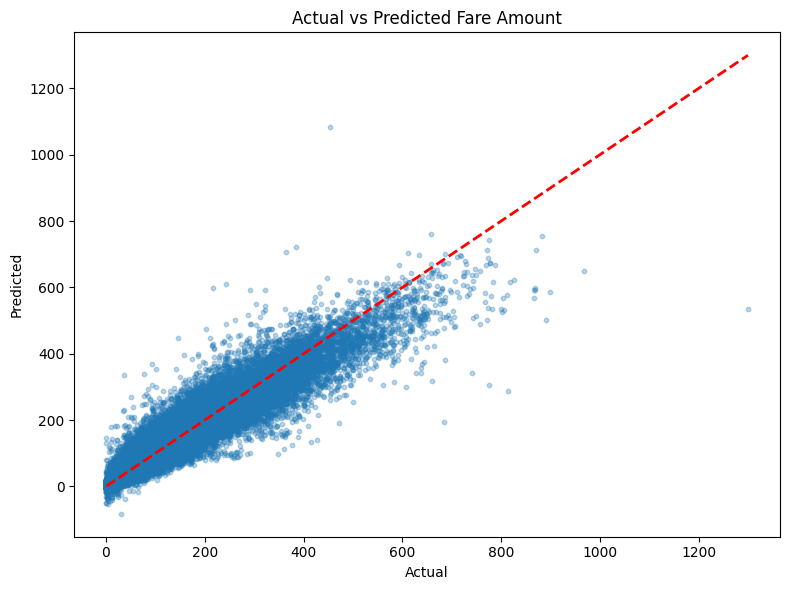

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

dfOneHot = dfOneHot.with_columns(
    (pl.col('PULocationID').cast(str) + '_' + pl.col('hour').cast(str)).alias('loc_hour_key')
)

dfOneHot = dfOneHot.sort(['PULocationID', 'tpep_pickup_datetime'])

# 3. Create the 1-hour and 2-hour lag features using window functions globally
dfOneHot = dfOneHot.with_columns([
    pl.col('trip_count').shift(1).over('PULocationID').alias('trip_count_lag_1h'),
    pl.col('trip_count').shift(2).over('PULocationID').alias('trip_count_lag_2h')
])

#One Hot Dataframe- Train and Test Split
trainOneHot = dfOneHot.filter(pl.col('tpep_pickup_datetime') < split_date)
testOneHot = dfOneHot.filter(pl.col('tpep_pickup_datetime') >= split_date)

loc_hour_avg = (
    trainOneHot.group_by('loc_hour_key')
    .agg(pl.col('trip_count').mean().alias('loc_hour_avg'))
)
global_avg = trainOneHot['trip_count'].mean()

trainOneHot = trainOneHot.join(loc_hour_avg, on='loc_hour_key', how='left')
testOneHot = testOneHot.join(loc_hour_avg, on='loc_hour_key', how='left')
testOneHot = testOneHot.with_columns(pl.col('loc_hour_avg').fill_null(global_avg))


# Now we fill the missing boundary lags safely using our localized hourly average
trainOneHot = trainOneHot.with_columns([
    pl.col('trip_count_lag_1h').fill_null(pl.col('loc_hour_avg')),
    pl.col('trip_count_lag_2h').fill_null(pl.col('loc_hour_avg'))
])

testOneHot = testOneHot.with_columns([
    pl.col('trip_count_lag_1h').fill_null(pl.col('loc_hour_avg')),
    pl.col('trip_count_lag_2h').fill_null(pl.col('loc_hour_avg'))
])


trainOneHot = trainOneHot.drop(['loc_hour_key'])
testOneHot = testOneHot.drop(['loc_hour_key'])

# Step 2: recombine to one-hot encode consistently, then re-split
combined = pl.concat([trainOneHot.with_columns(pl.lit('train').alias('_split')),
                       testOneHot.with_columns(pl.lit('test').alias('_split'))])


combined = combined.to_dummies(Catcolumns, drop_first=True)

combined = combined.with_columns([
    (2 * np.pi * pl.col('hour') / 24).sin().alias('hour_sin'),
    (2 * np.pi * pl.col('hour') / 24).cos().alias('hour_cos')
])

finalDf = combined.clone()
combined = combined.drop('tpep_pickup_datetime')
trainOneHot = combined.filter(pl.col('_split') == 'train').drop('_split')
testOneHot = combined.filter(pl.col('_split') == 'test').drop('_split')



trainOneHot = trainOneHot.to_pandas()
testOneHot = testOneHot.to_pandas()




X_trainL, y_trainL = trainOneHot.drop(columns = 'trip_count'), trainOneHot['trip_count']
X_testL, y_testL = testOneHot.drop(columns = 'trip_count'), testOneHot['trip_count']


X_trainL = X_trainL.drop(columns=['hour'])
X_testL = X_testL.drop(columns=['hour'])





#Linear Regression Model

linearModel = LinearRegression()
linearModel.fit(X_trainL, y_trainL)

y_predL = linearModel.predict(X_testL)

mse = mean_squared_error(y_true = y_testL, y_pred = y_predL)
rmse = np.sqrt(mse)
r2 = r2_score(y_testL, y_predL)
print(f"RMSE: {rmse:.4f}")
print(f"R² Score: {r2:.4f}")



plt.figure(figsize=(8, 6))
plt.scatter(y_testL, y_predL, alpha=0.3, s=10)
plt.plot([y_testL.min(), y_testL.max()], [y_testL.min(), y_testL.max()], 'r--', linewidth=2)

plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted Fare Amount')

plt.tight_layout()
plt.show()



In [ ]:
print(X_trainL['year'].unique())
print(X_testL['year'].unique())

print(X_trainL['month'].unique())
print(X_testL['month'].unique())

print(X_trainL['day_of_month'].unique())
print(X_testL['day_of_month'].unique())

[2025]
[2025]
[ 1  2  3  4  5  6  7  8  9 10]
[10 11 12]
[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31]
[31  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30]


In [ ]:
print("Predictions sample:", y_predL[:10])
print("Actual sample:", y_testL.values[:10])
print("\nPrediction stats:")
print(pd.Series(y_predL).describe())
print("\nActual stats:")
print(y_testL.describe())

Predictions sample: [0.95842204 1.91374697 3.71020127 4.05094827 6.32938909 4.00279227
 3.85494694 6.10648188 4.63655393 8.87502818]
Actual sample: [ 1  1  1  3  1  1  4  4 10  1]

Prediction stats:
count    250558.000000
mean         34.724006
std          71.362282
min         -82.363396
25%           2.741377
50%           6.068154
75%          23.072648
max        1083.975949
dtype: float64

Actual stats:
count    250558.000000
mean         34.578142
std          74.645849
min           1.000000
25%           2.000000
50%           5.000000
75%          23.000000
max        1300.000000
Name: trip_count, dtype: float64


In [ ]:
print(testOneHot.shape)
print(trainOneHot.shape)

(250558, 278)
(1179716, 278)


In [ ]:
coef_df = pd.DataFrame({'feature': X_trainL.columns, 'coef': linearModel.coef_})
print(coef_df.sort_values('coef', key=abs, ascending=False).head(15))

                 feature      coef
266    day_factor_Monday -2.445237
275             hour_cos -2.128945
113     PULocationID_204  1.938544
268    day_factor_Sunday -1.476011
200      PULocationID_44  1.334766
106     PULocationID_199  1.329318
260      PULocationID_99  1.172944
214      PULocationID_57  1.161620
181      PULocationID_27  1.128114
267  day_factor_Saturday  1.041953
167     PULocationID_253  1.032448
274             hour_sin  0.949041
149     PULocationID_237 -0.947634
65      PULocationID_161 -0.942816
33      PULocationID_132 -0.936113


## SARIMAX Testing

Only Testing on one specific zone as SARIMAX doesn't perform well when using a feature with 250+ location codes

--- Processing Zone: 230 ---
Cleaned DataFrame Shape: (8754, 7)
Training observations: 7270 | Testing observations: 1484
Fitting SARIMAX model... (This may take a moment due to seasonal cycles)


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



================ EVALUATION ================
SARIMAX RMSE: 60.3337
SARIMAX R² Score: 0.7017



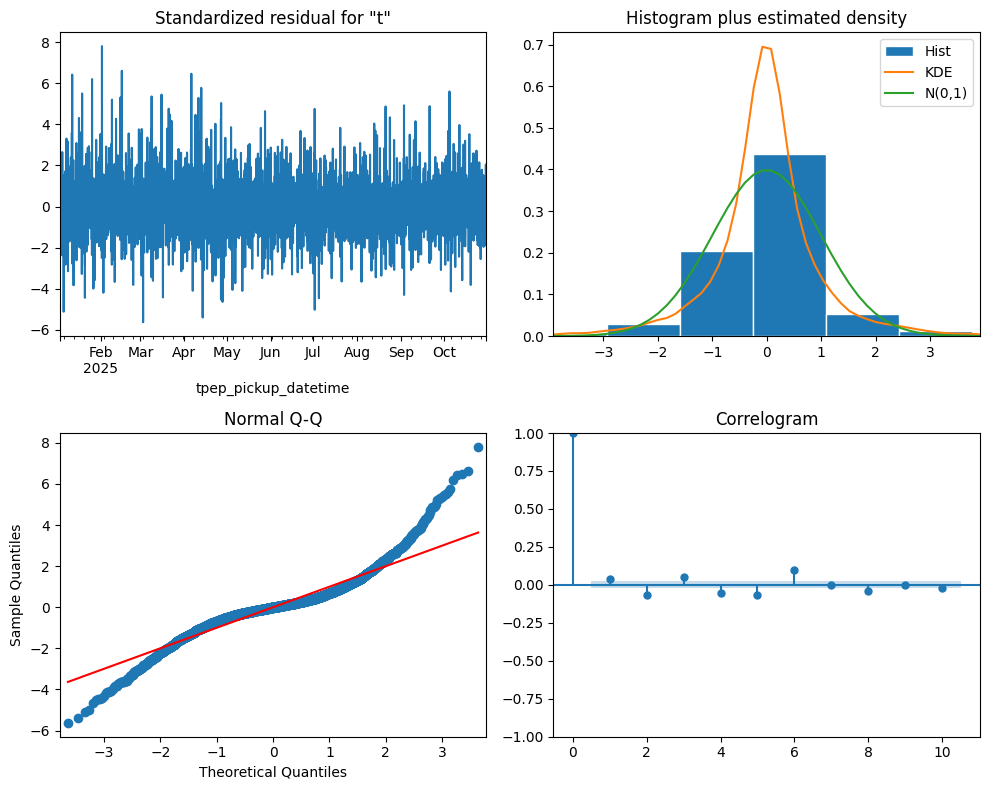

In [ ]:
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.tsa.statespace.sarimax import SARIMAX



# ==========================================
# 1. ISOLATE THE TARGET ZONE
# ==========================================
# Extract the list of unique zones and pick the first active one
unique_zones = df['PULocationID'].unique().to_list()
zone_id = 230

# Filter down to just this zone and sort chronologically
zone_df = df.filter(pl.col('PULocationID') == zone_id).sort('tpep_pickup_datetime')

# ==========================================
# 2. CONVERT TO PANDAS & HOURLY RESAMPLE
# ==========================================
zone_pd = zone_df.to_pandas()
zone_pd['tpep_pickup_datetime'] = pd.to_datetime(zone_pd['tpep_pickup_datetime'])
zone_pd.set_index('tpep_pickup_datetime', inplace=True)

# Map our original features to aggregation rules
agg_dict = {
    'trip_count': 'sum',          # Aggregate total trips per hour
    'hour': 'first',
    'day_of_month': 'first',
    'year': 'first',
    'month': 'first',
    'is_weekend': 'first',
    'day_factor': 'first'
}

# Resample to hourly intervals to fill structural gaps with zeros
zone_pd = zone_pd.resample('h').agg(agg_dict)

# Re-align physical time parameters for manufactured empty hours
zone_pd['hour'] = zone_pd.index.hour
zone_pd['day_of_month'] = zone_pd.index.day
zone_pd['year'] = zone_pd.index.year
zone_pd['month'] = zone_pd.index.month

# Forward and backward fill static categorical/boolean flags
zone_pd = zone_pd.ffill().bfill()

print(f"--- Processing Zone: {zone_id} ---")
print("Cleaned DataFrame Shape:", zone_pd.shape)

# ==========================================
# 3. TRAIN / TEST SPLIT & EXOG SET-UP
# ==========================================
# Cut the dataframe chronologically around your split_date
train_zone = zone_pd[zone_pd.index < split_date]
test_zone = zone_pd[zone_pd.index >= split_date]

# Define purely numeric exogenous columns (Dropping target & text factor strings)
exog_cols = ['hour', 'day_of_month', 'year', 'month', 'is_weekend']

X_train_exog = train_zone[exog_cols].astype(float)
X_test_exog = test_zone[exog_cols].astype(float)

y_train = train_zone['trip_count']
y_test = test_zone['trip_count']

print(f"Training observations: {len(train_zone)} | Testing observations: {len(test_zone)}")

# ==========================================
# 4. DEFINE AND FIT THE SARIMAX MODEL
# ==========================================
# order=(p,d,q), seasonal_order=(P,D,Q,s)
model = SARIMAX(
    endog=y_train,
    exog=X_train_exog,
    order=(1, 1, 1),              # Baseline Trend ARIMA components
    seasonal_order=(1, 1, 1, 24), # 24-hour daily seasonal pattern cycle
    enforce_stationarity=False,
    enforce_invertibility=False
)

print("Fitting SARIMAX model... (This may take a moment due to seasonal cycles)")
sarimax_res = model.fit(disp=False)

# ==========================================
# 5. FORECAST & EVALUATE
# ==========================================
# Generate predictions matching the exact step length of the test split
forecast_steps = len(test_zone)
predictions = sarimax_res.forecast(steps=forecast_steps, exog=X_test_exog)

# Handle potential structural NaNs safely
y_true_clean = y_test.fillna(0)
predictions_clean = predictions.fillna(0)

# Calculate standard metrics
mse = mean_squared_error(y_true=y_true_clean, y_pred=predictions_clean)
rmse = np.sqrt(mse)
r2 = r2_score(y_true_clean, predictions_clean)

print("\n================ EVALUATION ================")
print(f"SARIMAX RMSE: {rmse:.4f}")
print(f"SARIMAX R² Score: {r2:.4f}")
print("============================================\n")

# Optional: Plot the internal model fit quality diagnostics
sarimax_res.plot_diagnostics(figsize=(10, 8))
plt.tight_layout()
plt.show()

## XGBoost Testing

In [ ]:
#XGBoost Model
import xgboost as xgb

#Catcolumns = ['day_factor', 'PULocationID']

features = ["PULocationID", "hour",	"day_of_month",	"year",	"month",	"is_weekend",	"day_factor"]


xgModel = xgb.XGBRegressor(
    tree_method = 'hist',
    enable_categorical = True,
    n_estimators=300,     # Maximum number of sequential trees
    max_depth=6,          # Depth of each tree
    learning_rate=0.02,    # Step size shrinkage (eta)

)

xgModel.fit(X_trainL, y_trainL,
    eval_set=[(X_testL, y_testL)],
    verbose=100)


[0]	validation_0-rmse:73.27234
[100]	validation_0-rmse:19.27850
[200]	validation_0-rmse:15.38126
[299]	validation_0-rmse:14.89453


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.02, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
y_predX = xgModel.predict(X_testL)

mse = mean_squared_error(y_true = y_testL, y_pred = y_predX)
rmse = np.sqrt(mse)
r2 = r2_score(y_testL, y_predX)
print(f"RMSE: {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

RMSE: 14.8945
R² Score: 0.9602


In [ ]:
finalDf.write_csv("/content/drive/MyDrive/Colab Notebooks/nyc-taxi-drift-forecasting/data/completeData.csv")